# Clasificación Automática de Modulaciones (AMC)
## Entrenamiento — CNN (representación Amplitud/Fase)

Este notebook entrena la misma arquitectura `CNNBaseline` de `../common/models.py` que usa
`../cnn/cnn.ipynb`, pero con la señal transformada a **Amplitud/Fase** (`to_amplitude_phase`
en `../common/data.py`) en vez de I/Q crudo. Como A/φ también tiene 2 canales, no hace falta
tocar la arquitectura — solo se transforma la entrada después del split. Sirve para comparar,
con la arquitectura fija, qué representación conviene más para el objetivo de liviandad del
proyecto (¿la misma CNN rinde igual o mejor con menos ambigüedad en la fase que con I/Q?).

Para probar otra profundidad/ancho, modificar `MODEL_KWARGS` más abajo y volver a correr el
notebook — la config usada queda guardada en `history.pkl` junto con el historial de
entrenamiento, así `comparacion.ipynb` puede reconstruir el modelo exacto antes de cargar los
pesos.


## 1. Imports y configuración

In [1]:
import sys
sys.path.insert(0, "..")

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common.models import CNNBaseline
from common.data import load_radioml_digital, split_dataset, make_loader, to_amplitude_phase
from common.train import train_model, evaluate_by_snr, overall_accuracy, compute_cm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
EPOCHS = 50
PATIENCE = 10
SEED = 42

# Hiperparámetros de arquitectura — modificar acá para probar otra profundidad/ancho.
# No incluye n_classes (se completa con el dataset) para poder reusar la misma config
# sin importar cuántas clases tenga el split.
MODEL_KWARGS = dict(channels=(64, 64), kernel_size=3, fc_hidden=128, dropout=0.5)

print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## 2. Carga y preparación del dataset (I/Q → Amplitud/Fase)

In [2]:
X, y, snrs, le = load_radioml_digital(seed=SEED)
N_CLASSES = len(le.classes_)
print(f"Clases ({N_CLASSES}): {list(le.classes_)}")

(X_train, y_train, snr_train), (X_val, y_val, snr_val), (X_test, y_test, snr_test) = split_dataset(
    X, y, snrs, seed=SEED
)

# Mismo split (misma semilla) que cnn/, lstm/, gru/, tcn/ — se transforma recién acá para
# que la comparación entre representaciones use exactamente las mismas señales de origen.
X_train = to_amplitude_phase(X_train)
X_val = to_amplitude_phase(X_val)
X_test = to_amplitude_phase(X_test)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

Clases (8): ['8PSK', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK']
Train: (96000, 2, 128) | Val: (32000, 2, 128) | Test: (32000, 2, 128)


## 3. Entrenamiento — CNN (A/φ)

In [3]:
print("=== CNN (A/\u03c6) ===")
print(f"Configuración: {MODEL_KWARGS}")
model = CNNBaseline(n_classes=N_CLASSES, **MODEL_KWARGS)
print(f"Parámetros: {model.count_parameters():,}")

model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, device=DEVICE
)
history["model_kwargs"] = MODEL_KWARGS

torch.save(model.state_dict(), "cnn_ap.pt")
with open("history.pkl", "wb") as f:
    pickle.dump(history, f)

=== CNN (A/φ) ===
Configuración: {'channels': (64, 64), 'kernel_size': 3, 'fc_hidden': 128, 'dropout': 0.5}
Parámetros: 1,063,048
Época  10/50 | Train Loss: 0.9756 | Val Loss: 1.1338 | Val Acc: 0.5203 | Patience: 0/10
Época  20/50 | Train Loss: 0.6482 | Val Loss: 1.3513 | Val Acc: 0.5255 | Patience: 10/10
Early stopping en época 20. Mejor val_loss: 1.1338


## 4. Evaluación

In [4]:
acc = overall_accuracy(model, X_test, y_test, device=DEVICE)
snr_acc = evaluate_by_snr(model, X_test, y_test, snr_test, device=DEVICE)

print(f"Accuracy global — CNN (A/\u03c6): {acc:.4f}")
print(f"Parámetros: {model.count_parameters():,}")

Accuracy global — CNN (A/φ): 0.5213
Parámetros: 1,063,048


## 5. Gráficos

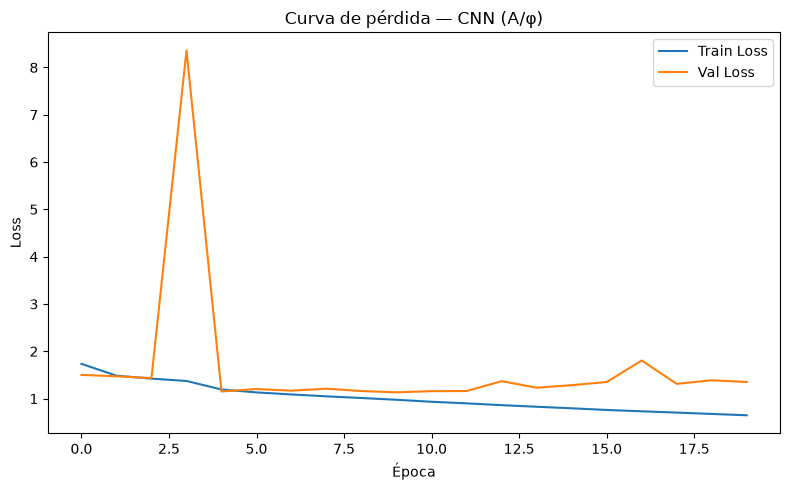

In [5]:
# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida — CNN (A/\u03c6)")
plt.legend()
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=150)
plt.show()

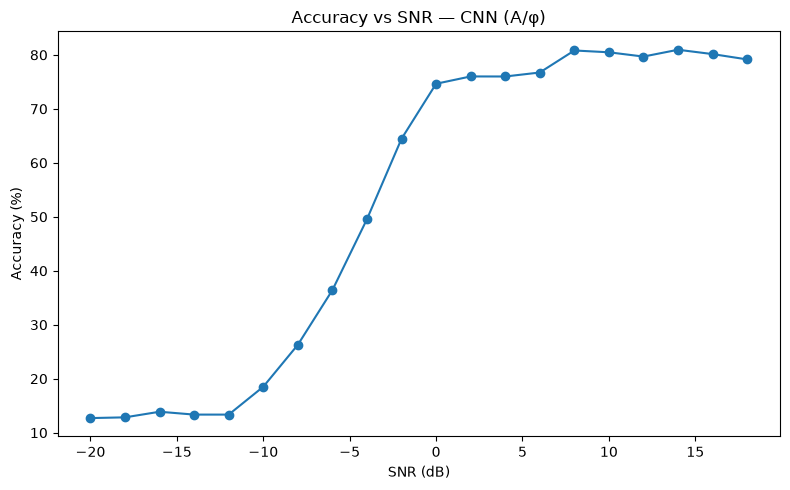

In [6]:
# Accuracy vs SNR
snr_levels = sorted(snr_acc.keys())
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — CNN (A/\u03c6)")
plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150)
plt.show()

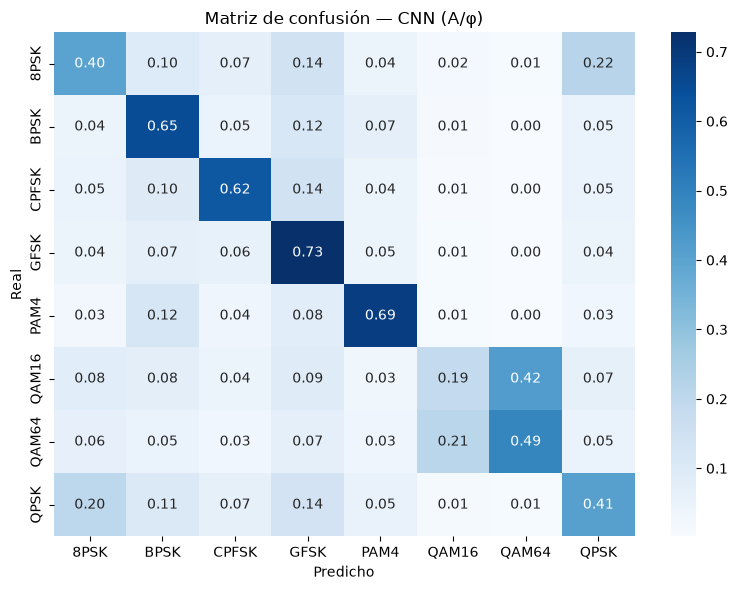

In [7]:
# Matriz de confusión (todos los SNR)
cm = compute_cm(model, X_test, y_test, device=DEVICE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CNN (A/\u03c6)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

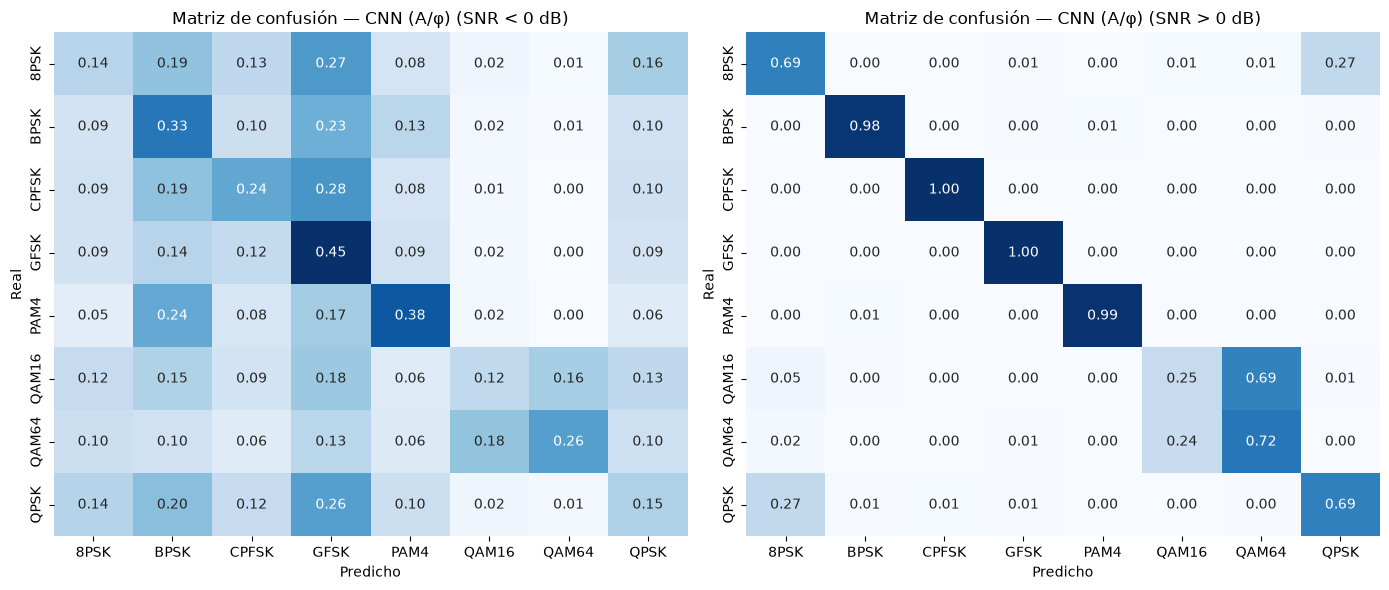

In [8]:
# Matrices de confusión por rango de SNR (bajo: <0 dB, alto: >0 dB)
mask_low = snr_test < 0
mask_high = snr_test > 0

cm_low = compute_cm(model, X_test[mask_low], y_test[mask_low], device=DEVICE)
cm_high = compute_cm(model, X_test[mask_high], y_test[mask_high], device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm_snr, titulo in zip(axes, [cm_low, cm_high], ["SNR < 0 dB", "SNR > 0 dB"]):
    sns.heatmap(cm_snr, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — CNN (A/\u03c6) ({titulo})")
plt.tight_layout()
plt.savefig("confusion_matrix_por_snr.png", dpi=150)
plt.show()